# Setup

## Imports

Load AlphaGenome client, genome/transcript helpers, and plotting. API keys are read from `.env` as numbered `AG_API_KEY_*` variables.


In [1]:
from alphagenome.models import dna_client
from alphagenome.data import gene_annotation, genome, transcript, track_data
from alphagenome.visualization import plot_components
import pandas as pd
import os
from dotenv import load_dotenv
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
load_dotenv(dotenv_path=".env")
API_KEYS = [v for _, v in sorted(
    ((k, os.environ[k].strip()) for k in os.environ
     if k.startswith("AG_API_KEY_") and k.removeprefix("AG_API_KEY_").isdigit()),
    key=lambda kv: int(kv[0].removeprefix("AG_API_KEY_")),
) if v]


## Paths and constants

LMNA MANE coordinates, GENCODE v46 GTF, left-ventricle ontology, and the top-1% ISM variant list from `ISM_analysis.ipynb`.


In [6]:
gene_symbol = "LMNA"
# MANE transcript chr1:156,114,711-156,140,081 (minus strand)
LMNA_INTERVAL = genome.Interval('chr1', 156_114_711, 156_140_081)

BASE_PATH = '/users/PAS2905/coraalbers/'
AG_DATA_PATH = '/users/PAS2905/coraalbers/ag/ag_data/'
HG38_GTF_PATH = f'{AG_DATA_PATH}gencode.v46.annotation.gtf.gz.feather'

LV_UB = 'UBERON:0002084'

gtf = pd.read_feather(HG38_GTF_PATH)

VARIANTS_PATH = f'{BASE_PATH}ag/variant-effects/osc/outputs/ism_ccres_top1_variant_strings.txt'

save = False


## Load model

Create the AlphaGenome API client.


In [3]:
model = dna_client.create(API_KEYS[4])

print('API model initialized!')


API model initialized!


# Variants

## Load top 1% ISM variants

Read `chr:pos:ref>alt` strings and build a table of SNVs to visualize.


In [66]:
def get_variants(variant_path):
    variants = []
    with open(variant_path, "r") as f:
        for line in f:
            line = line.replace('>', ":")
            variants.append(line.strip().split(":"))
    return variants


variant_list = get_variants(VARIANTS_PATH)
variant_df = pd.DataFrame(variant_list, columns=['CHROM', 'POS', 'REF', 'ALT'])
variant_df


lmna_variants = []
for idx, row in variant_df.iterrows():
    if int(row.POS) in range(156_114_711, 156_140_081):
        lmna_variants.append(row)

lmna_variants_df = pd.DataFrame(lmna_variants, columns=['CHROM', 'POS', 'REF', 'ALT']).reset_index()


## Map variants on the genome

Plot every SNV in `variant_df` on chr1. The annotation track shows the LMNA gene body, MANE transcript, and predicted central-LV cCREs so the ISM clusters are readable.

In [ ]:
pos = variant_df['POS'].astype(int)
chrom = variant_df['CHROM'].iloc[0]

gene_rows = gtf[(gtf['gene_name'] == gene_symbol) & (gtf['Feature'] == 'gene')]
if gene_rows.empty:
    gene_start, gene_end = LMNA_INTERVAL.start, LMNA_INTERVAL.end
else:
    gene_start = int(gene_rows['Start'].min())
    gene_end = int(gene_rows['End'].max())

ccre_bed_path = (
    f'{BASE_PATH}ag/variant-effects/osc/data_sync/'
    'predicted_ccre_like_regions_central_LV_128res.bed'
)
ccre_df = pd.read_csv(ccre_bed_path, sep='\t')

pad = 20_000
plot_start = min(int(pos.min()), gene_start, int(ccre_df['start'].min())) - pad
plot_end = max(int(pos.max()), gene_end, int(ccre_df['end'].max())) + pad

fig, (ax_ann, ax_var) = plt.subplots(
    2, 1, figsize=(14, 3.8), sharex=True,
    gridspec_kw={'height_ratios': [1.3, 2.2], 'hspace': 0.08},
)

ax_ann.broken_barh(
    [(gene_start, gene_end - gene_start)], (2.15, 0.55), facecolor='0.25',
)
ax_ann.broken_barh(
    [(LMNA_INTERVAL.start, LMNA_INTERVAL.width)], (1.4, 0.55), facecolor='steelblue',
)
for _, row in ccre_df.iterrows():
    ax_ann.broken_barh(
        [(int(row['start']), int(row['end']) - int(row['start']))],
        (0.35, 0.75),
        facecolor='darkorange',
        alpha=0.75,
    )
ax_ann.set_yticks([0.7, 1.65, 2.4])
ax_ann.set_yticklabels(['predicted cCREs', 'MANE', f'{gene_symbol}'])
ax_ann.set_ylim(0, 2.9)
ax_ann.spines['top'].set_visible(False)
ax_ann.spines['right'].set_visible(False)
ax_ann.spines['bottom'].set_visible(False)
ax_ann.tick_params(axis='x', bottom=False, labelbottom=False)

ax_var.hist(pos, bins=400, color='crimson', alpha=0.85)
ax_var.plot(pos, [0] * len(pos), '|', color='crimson', markersize=8, alpha=0.45)
ax_var.set_xlim(plot_start, plot_end)
ax_var.set_xlabel(f'{chrom} position (hg38)')
ax_var.set_ylabel('SNV count')
ax_var.spines['top'].set_visible(False)
ax_var.spines['right'].set_visible(False)

fig.suptitle(
    f'Top 1% ISM variants (n={len(variant_df):,}) on {chrom}',
    y=0.98,
)
plt.show()

if save:
    fig.savefig(
        f'{BASE_PATH}ag/variant-effects/osc/figs/ism_top1_variant_locations.png',
        dpi=300,
        bbox_inches='tight',
    )

print(
    f'{chrom}:{plot_start:,}-{plot_end:,}  '
    f'variants {int(pos.min()):,}-{int(pos.max()):,}  '
    f'n={len(variant_df):,}'
)

## Select a variant

Use the first row of `variant_df` (change `iloc` to pick another). Resize the MANE interval to 500 kb for `predict_variant`.


In [67]:
terms = lmna_variants_df.iloc[99]
variant_chromosome = terms.CHROM
variant_position = int(terms.POS)
variant_reference_bases = terms.REF
variant_alternate_bases = terms.ALT

variant = genome.Variant(
    chromosome=variant_chromosome,
    position=variant_position,
    reference_bases=variant_reference_bases,
    alternate_bases=variant_alternate_bases,
)

organism = dna_client.Organism.HOMO_SAPIENS
sequence_length = dna_client.SUPPORTED_SEQUENCE_LENGTHS['SEQUENCE_LENGTH_500KB']
interval = LMNA_INTERVAL.resize(sequence_length)

print(variant)
print(f'prediction interval width: {interval.width}')


chr1:156126456:G>T
prediction interval width: 524288


# Predict and plot

Call `predict_variant` for left ventricle and render REF (grey) and ALT (red) as separate tracks for RNA-seq, splice sites, splice-site usage, and splice junctions. Sashimi uses `interval_contained=False` so junctions that overlap the plot window are drawn even if they extend past it. The figure is written under `variant-effects/osc/figs/` if `save` is True.


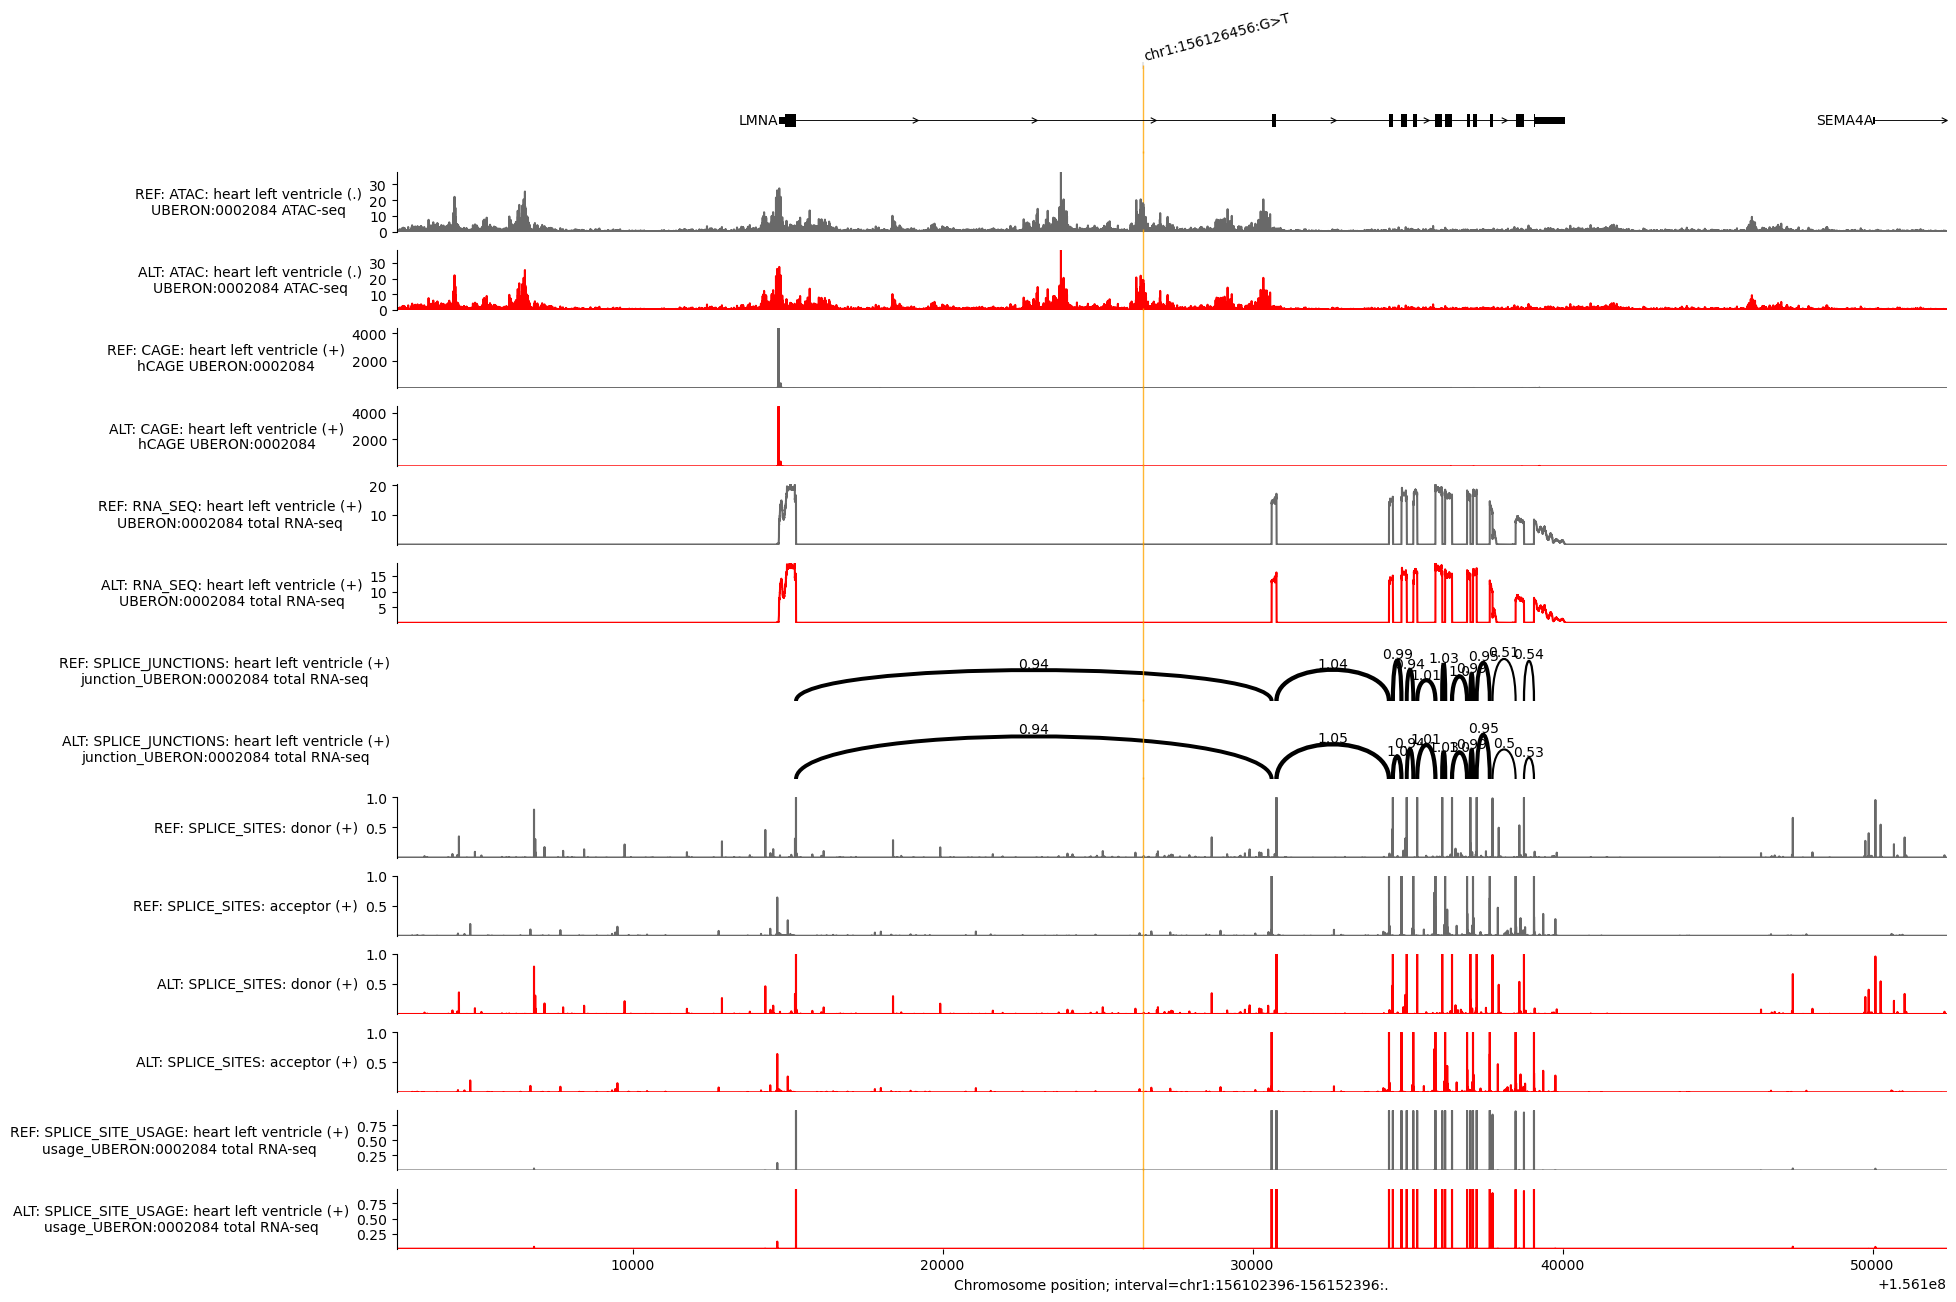

In [68]:
# Initialize an empty dictionary to serve as a variant effect prediction cache.
_prediction_cache = {}

_transcript_extractor_cache = {}


# @title Visualize variant effects { run: "auto" }
# @markdown We can also visualise the predicted effects of the variant by first predicting tracks for the REF and ALT alleles:

# @markdown Specify list of cell and tissue ontologies:
ontology_terms = [LV_UB]  # @param

# @markdown Gene and transcript annotation options:
plot_gene_annotation = True  # @param { type: "boolean" }
plot_longest_transcript_only = True  # @param { type: "boolean" }

# @markdown Output types to plot (if present in output):
plot_rna_seq = True  # @param { type: "boolean" }
plot_cage = True  # @param { type: "boolean" }
plot_atac = True  # @param { type: "boolean" }
plot_dnase = False  # @param { type: "boolean" }
plot_chip_histone = False  # @param { type: "boolean" }
plot_chip_tf = False  # @param { type: "boolean" }
plot_splice_sites = True  # @param { type: "boolean" }
plot_splice_site_usage = True  # @param { type: "boolean" }
plot_contact_maps = False  # @param { type: "boolean" }
plot_splice_junctions = True  # @param { type: "boolean" }

# @markdown Specify a list of Transription Factors to select from CHIP_TF outputs e.g. ['IKZF1'].
# These must be contained in the 'transcription_factor' column of the CHIP_TF metadata.
transcription_factors = None  # @param

# @markdown Other visualization options:
ref_color = 'dimgrey'  # @param { type: "string" }
alt_color = 'red'  # @param { type: "string" }
plot_interval_width = 50000 # @param { type: "slider", min: 2048, max: 1048576, step: 2048}
plot_interval_shift = 0 # @param { type: "slider", min: -524288, max: 524288, step: 2048}


# Load gene annotation.
if organism in _transcript_extractor_cache:
  transcript_extractor, longest_transcript_extractor = (
      _transcript_extractor_cache[organism]
  )
else:
  match organism:
    case dna_client.Organism.HOMO_SAPIENS:
      gtf_path = HG38_GTF_PATH
    case dna_client.Organism.MUS_MUSCULUS:
      gtf_path = MM10_GTF_FEATHER
    case _:
      raise ValueError(f'Unsupported organism: {organism}')

  gtf = pd.read_feather(gtf_path)

  # Filter to protein-coding genes and highly supported transcripts.
  gtf_transcript = gene_annotation.filter_transcript_support_level(
      gene_annotation.filter_protein_coding(gtf), ['1']
  )

  # Extractor for identifying transcripts in a region.
  transcript_extractor = transcript.TranscriptExtractor(gtf_transcript)

  # Also define an extractor that fetches only the longest transcript per gene.
  gtf_longest_transcript = gene_annotation.filter_to_longest_transcript(
      gtf_transcript
  )
  longest_transcript_extractor = transcript.TranscriptExtractor(
      gtf_longest_transcript
  )
  _transcript_extractor_cache[organism] = (
      transcript_extractor,
      longest_transcript_extractor,
  )


def _predict_variant_cached(
    interval, variant, organism, requested_outputs, ontology_terms
):
  """Cache wrapper of dna_model.predict_variant."""
  # Create a unique key from the function arguments.
  cache_key = (
      str(interval),
      str(variant),
      str(organism),
      tuple(requested_outputs),
      tuple(ontology_terms),
  )

  # Check if the result is already in the cache.
  if cache_key in _prediction_cache:
    return _prediction_cache[cache_key]

  # If not, compute the prediction and store it in the cache.
  result = model.predict_variant(
      interval=interval,
      variant=variant,
      organism=organism,
      requested_outputs=requested_outputs,
      ontology_terms=ontology_terms,
  )
  _prediction_cache[cache_key] = result
  return result


output = _predict_variant_cached(
    interval=interval,
    variant=variant,
    organism=organism,
    requested_outputs=[*dna_client.OutputType],
    ontology_terms=ontology_terms,
)

# Filter to DNA strand if requested.
ref, alt = output.reference, output.alternate

# Function to filter to TFs if requested.


def _filter_total_rna_seq(tdata):
    if tdata is None:
        return tdata
    if 'Assay title' not in tdata.metadata.columns:
        return tdata
    mask = (tdata.metadata['Assay title'] == 'total RNA-seq').to_numpy()
    if not mask.any():
        return tdata
    return tdata.filter_tracks(mask)


def _plus_or_unstranded(data):
    """Keep plus-strand and unstranded tracks/junctions; drop minus strand."""
    if data is None:
        return data
    if hasattr(data, 'filter_to_nonnegative_strand'):
        return data.filter_to_nonnegative_strand()
    mask = (data.strands == genome.STRAND_POSITIVE) | (
        data.strands == genome.STRAND_UNSTRANDED
    )
    return type(data)(
        junctions=data.junctions[mask],
        values=data.values[mask, :],
        metadata=data.metadata,
        interval=data.interval,
        uns=data.uns,
    )


def _maybe_filter_to_tfs(
    tdata: track_data.TrackData,
) -> track_data.TrackData | None:
  if not plot_chip_tf:
    return tdata

  if plot_chip_tf and (transcription_factors is not None):
    if not isinstance(transcription_factors, list):
      raise ValueError('TFs must be input as a list of strings.')
    if not isinstance(transcription_factors[0], str):
      raise ValueError('TFs must be input as a list of strings.')

  if transcription_factors is None:
    return tdata

  tf_rows = tdata.metadata.index[
      tdata.metadata['transcription_factor'].isin(transcription_factors)
  ]
  if not tf_rows.any():
    print(
        f'No tracks found for specified transcription factors and'
        f' ontology_terms.'
    )
    return None
  missing_tfs = set(transcription_factors).difference(
      set(tdata.metadata['transcription_factor'])
  )
  if missing_tfs:
    print(
        f'Could not find tracks in chip_tf outputs corresponding to the'
        f' following requested TFs'
    )
  return tdata.select_tracks_by_index(tf_rows)


# Build plot.
components = []

# Gene and transcript annotation.
if plot_gene_annotation:
  if plot_longest_transcript_only:
    transcripts = longest_transcript_extractor.extract(interval)
  else:
    transcripts = transcript_extractor.extract(interval)
  components.append(plot_components.TranscriptAnnotation(transcripts))


# Individual output type plots.
plot_map = {
    'plot_atac': (_plus_or_unstranded(ref.atac), _plus_or_unstranded(alt.atac), 'ATAC'),
    'plot_cage': (_plus_or_unstranded(ref.cage), _plus_or_unstranded(alt.cage), 'CAGE'),
    'plot_chip_histone': (_plus_or_unstranded(ref.chip_histone), _plus_or_unstranded(alt.chip_histone), 'CHIP_HISTONE'),
    'plot_chip_tf': (
        _plus_or_unstranded(_maybe_filter_to_tfs(ref.chip_tf)),
        _plus_or_unstranded(_maybe_filter_to_tfs(alt.chip_tf)),
        'CHIP_TF',
    ),
    'plot_contact_maps': (_plus_or_unstranded(ref.contact_maps), _plus_or_unstranded(alt.contact_maps), 'CONTACT_MAPS'),
    'plot_dnase': (_plus_or_unstranded(ref.dnase), _plus_or_unstranded(alt.dnase), 'DNASE'),
    'plot_rna_seq': (
        _plus_or_unstranded(_filter_total_rna_seq(ref.rna_seq)),
        _plus_or_unstranded(_filter_total_rna_seq(alt.rna_seq)),
        'RNA_SEQ',
    ),
    'plot_splice_junctions': (
        _plus_or_unstranded(_filter_total_rna_seq(ref.splice_junctions)),
        _plus_or_unstranded(_filter_total_rna_seq(alt.splice_junctions)),
        'SPLICE_JUNCTIONS',
    ),
    'plot_splice_sites': (
        _plus_or_unstranded(_filter_total_rna_seq(ref.splice_sites)),
        _plus_or_unstranded(_filter_total_rna_seq(alt.splice_sites)),
        'SPLICE_SITES',
    ),
    'plot_splice_site_usage': (
        _plus_or_unstranded(_filter_total_rna_seq(ref.splice_site_usage)),
        _plus_or_unstranded(_filter_total_rna_seq(alt.splice_site_usage)),
        'SPLICE_SITE_USAGE',
    ),
}

for key, (ref_data, alt_data, output_type) in plot_map.items():
  if eval(key) and ref_data is not None and ref_data.values.shape[-1] == 0:
    print(
        f'Requested plot for output {output_type} but no tracks exist in'
        ' output. This is likely because this output does not exist for your'
        ' ontologies or requested DNA strand.'
    )
  if eval(key) and ref_data and alt_data:
    match output_type:
      case 'CHIP_HISTONE':
        ylabel_template = (
            f'{output_type}: {{biosample_name}} ({{strand}})\n{{histone_mark}}'
        )
      case 'CHIP_TF':
        ylabel_template = (
            f'{output_type}: {{biosample_name}}'
            ' ({strand})\n{transcription_factor}'
        )
      case 'CONTACT_MAPS':
        ylabel_template = f'{output_type}: {{biosample_name}} ({{strand}})'
      case 'SPLICE_SITES':
        ylabel_template = f'{output_type}: {{name}} ({{strand}})'
      case _:
        ylabel_template = (
            f'{output_type}: {{biosample_name}} ({{strand}})\n{{name}}'
        )

    if output_type == 'CONTACT_MAPS':
      component = plot_components.ContactMapsDiff(
          tdata=alt_data - ref_data,
          ylabel_template=ylabel_template,
      )
      components.append(component)
    elif output_type == 'SPLICE_JUNCTIONS':
      ref_plot = plot_components.Sashimi(
          ref_data,
          ylabel_template='REF: ' + ylabel_template,
          interval_contained=False,
      )
      alt_plot = plot_components.Sashimi(
          alt_data,
          ylabel_template='ALT: ' + ylabel_template,
          interval_contained=False,
      )
      components.extend([ref_plot, alt_plot])
    else:
      ylims = (
          min(float(ref_data.values.min()), float(alt_data.values.min())),
          max(float(ref_data.values.max()), float(alt_data.values.max())),
      )
      components.extend([
          plot_components.Tracks(
              tdata=ref_data,
              track_colors=ref_color,
              ylabel_template='REF: ' + ylabel_template,
              global_ylims=ylims,
          ),
          plot_components.Tracks(
              tdata=alt_data,
              track_colors=alt_color,
              ylabel_template='ALT: ' + ylabel_template,
              global_ylims=ylims,
          ),
      ])

if plot_interval_width > interval.width:
  raise ValueError(
      f'plot_interval_width ({plot_interval_width}) must be less than '
      f'interval.width ({interval.width}).'
  )

plot = plot_components.plot(
    components=components,
    interval=LMNA_INTERVAL.shift(plot_interval_shift).resize(plot_interval_width),
    annotations=[
        plot_components.VariantAnnotation([variant]),
    ],
)


if save: 
    plt.savefig(f"{BASE_PATH}ag/variant-effects/osc/figs/ISM_predictions_{variant_chromosome}_{variant_position}_{variant_reference_bases}_{variant_alternate_bases}.png", dpi=300, bbox_inches="tight")
